[                       0%                       ]

TASK 1: Stock Universe Selection



[*********************100%***********************]  5 of 5 completed


✓ Data downloaded: 1235 trading days × 5 stocks
            HDFCBANK.NS  HINDUNILVR.NS      INFY.NS       M&M.NS  SUNPHARMA.NS
Date                                                                          
2025-12-26   992.099976    2285.399902  1656.099976  3623.100098   1708.402588
2025-12-29   991.700012    2293.300049  1644.699951  3592.100098   1706.117310
2025-12-30   990.900024    2290.199951  1621.599976  3660.300049   1709.098022

── Missing Values per Stock ──
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
M&M.NS           0
SUNPHARMA.NS     0
dtype: int64
✓ Forward-fill applied

── Rolling 30-Day Standard Deviation ──

Average Rolling Std Dev (higher = more volatile):
HDFCBANK.NS      19.68
HINDUNILVR.NS    60.18
INFY.NS          46.99
M&M.NS           65.13
SUNPHARMA.NS     30.86
dtype: float64


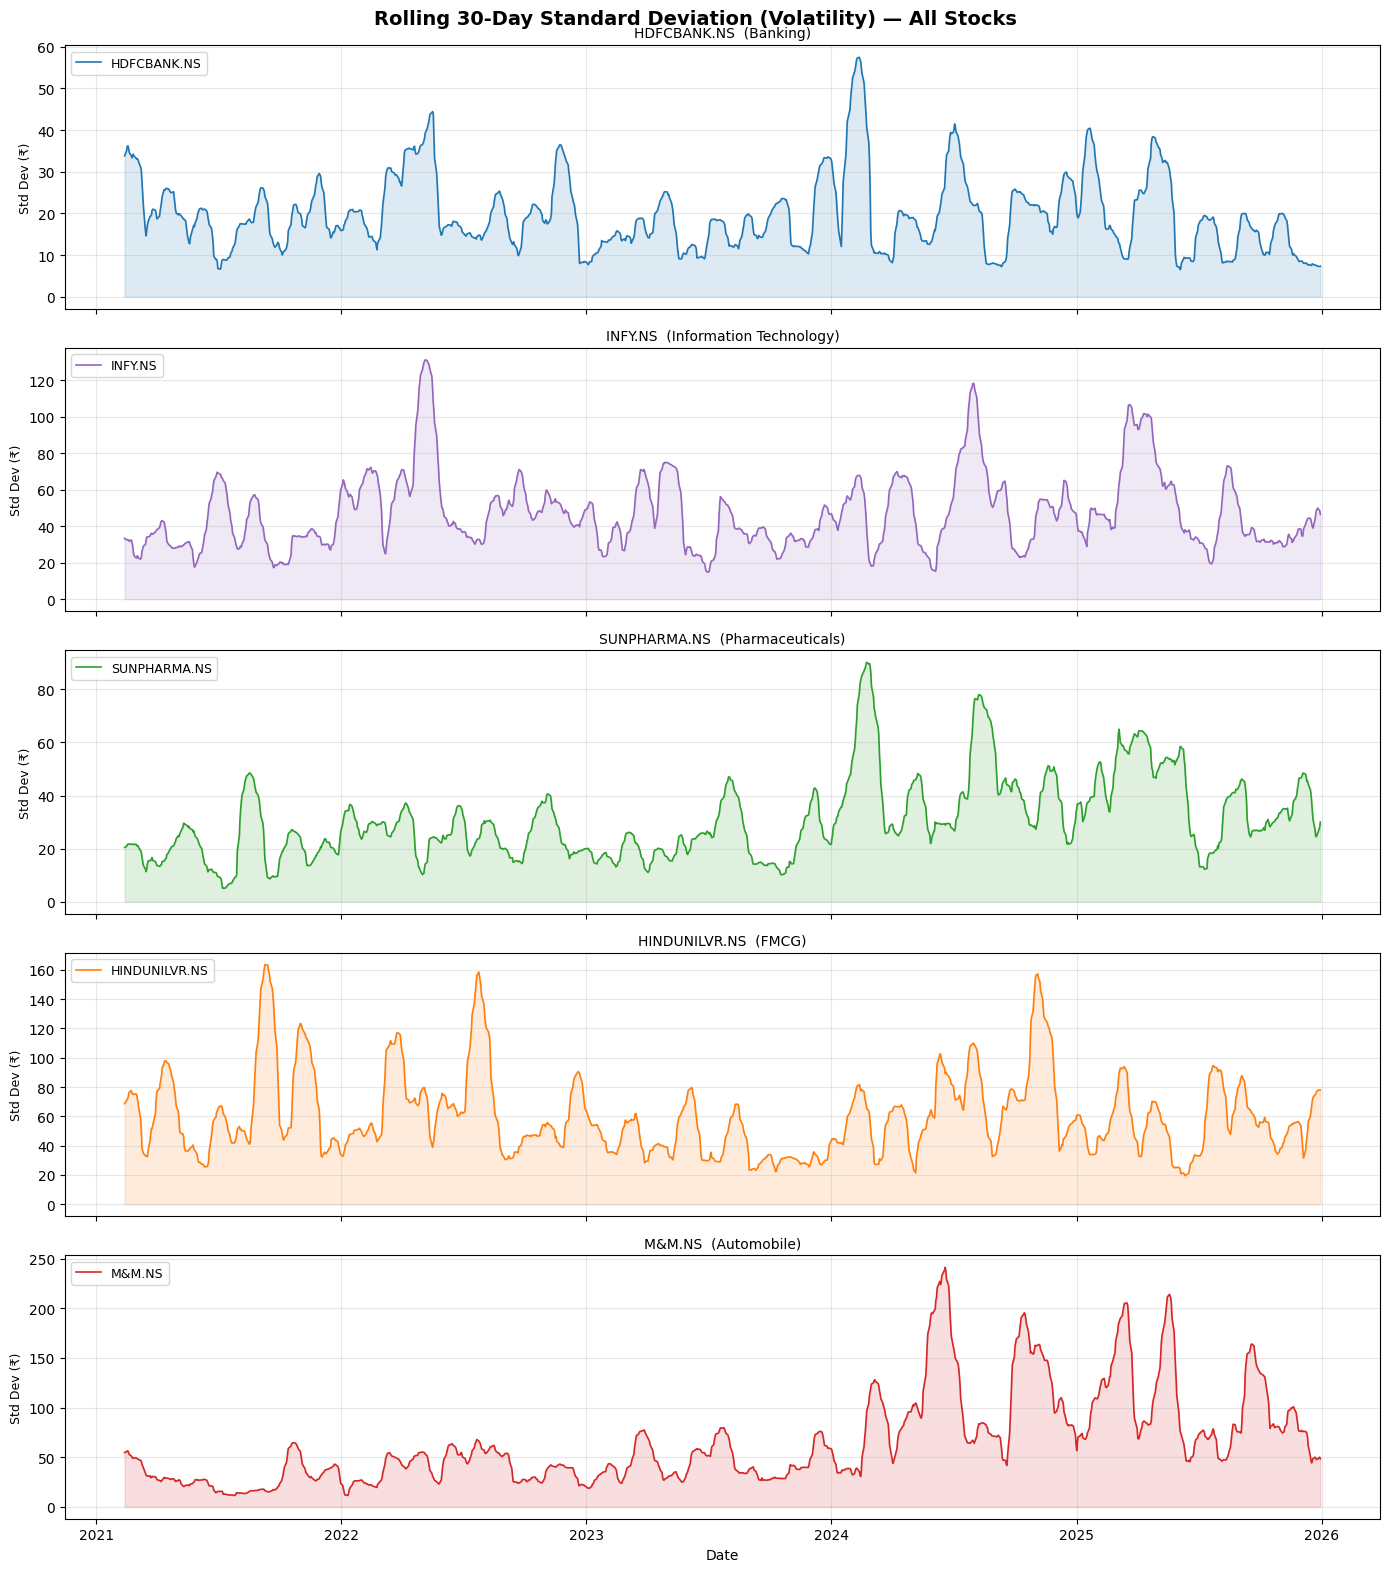

✓ Saved: task1_rolling_std_dev.png

── Augmented Dickey-Fuller (ADF) Stationarity Test ──
Stock                ADF Stat    p-value    Stationary?
--------------------------------------------------------
HDFCBANK.NS           -1.3959     0.5843 No ✗ (needs diff)
INFY.NS               -2.3999     0.1418 No ✗ (needs diff)
SUNPHARMA.NS          -0.8476     0.8047 No ✗ (needs diff)
HINDUNILVR.NS         -2.8815     0.0475          Yes ✓
M&M.NS                 0.6838     0.9895 No ✗ (needs diff)

Note: Non-stationary series will be differenced in Task 2.

── Seasonal Decomposition ──


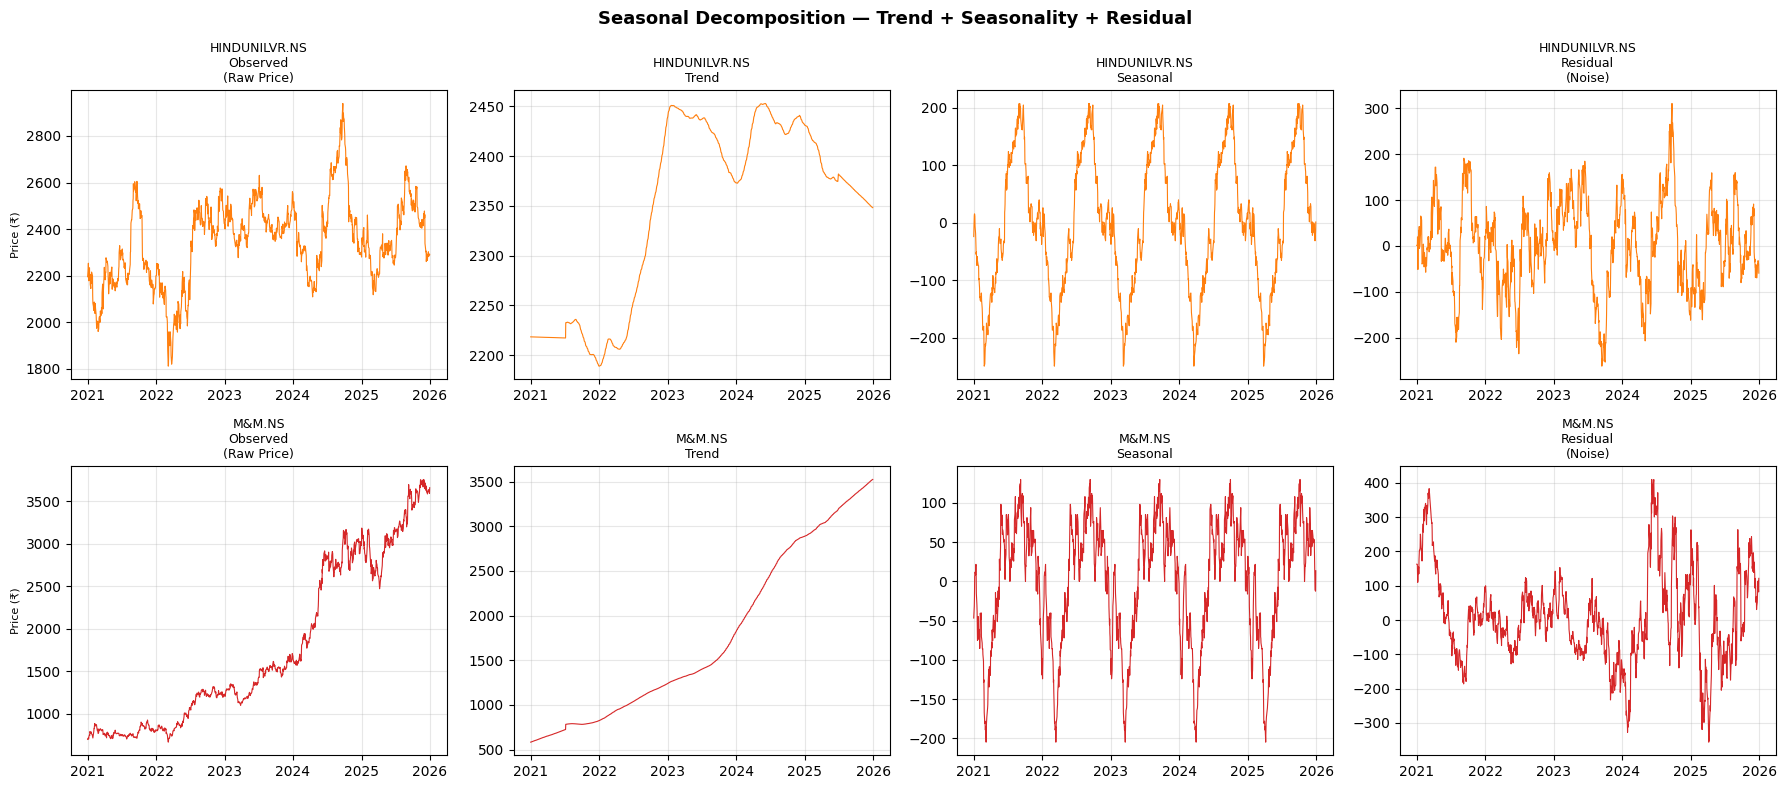

✓ Saved: task1_seasonal_decomposition.png

── Normalized Price Chart ──


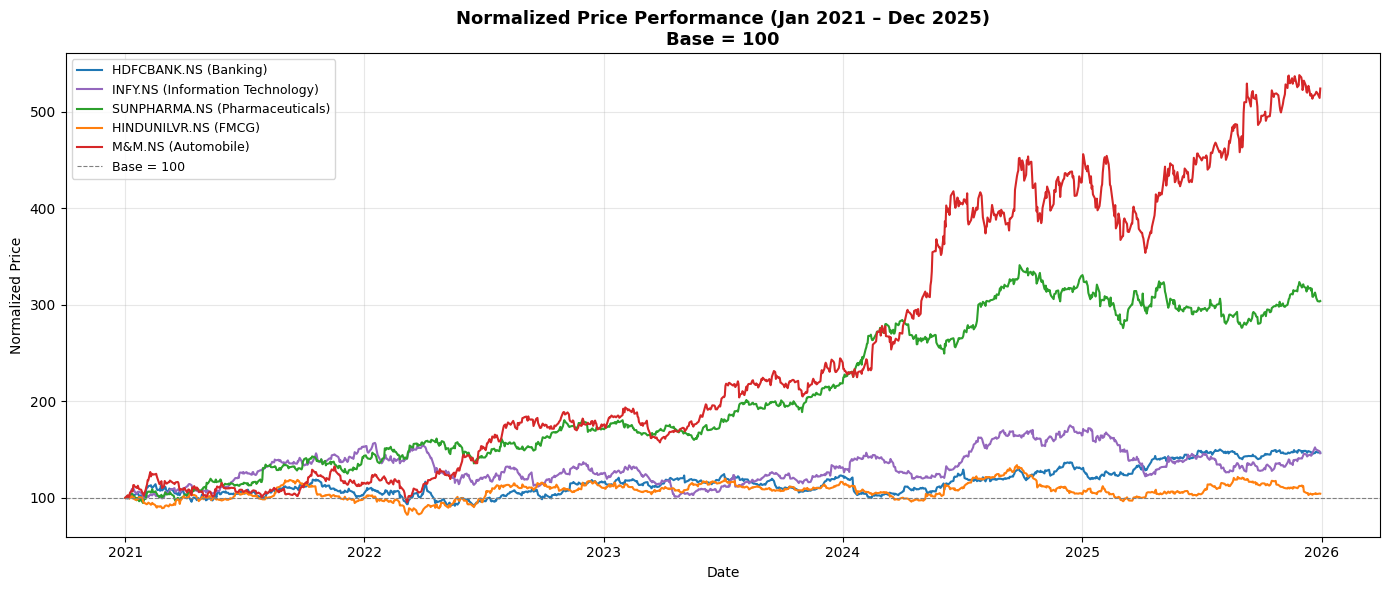

✓ Saved: task1_normalized_prices.png

── Sector Momentum: Last 6-Month Return ──
               6M Return (%)                  Sector
M&M.NS                 15.91              Automobile
SUNPHARMA.NS            2.99         Pharmaceuticals
INFY.NS                 2.79  Information Technology
HINDUNILVR.NS           0.59                    FMCG
HDFCBANK.NS            -0.74                 Banking


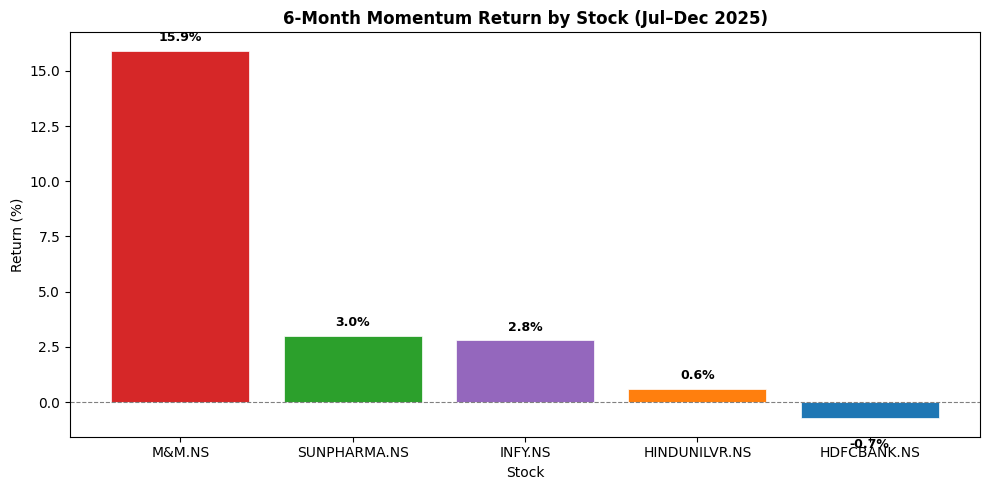

✓ Saved: task1_sector_momentum.png

FINAL STOCK SELECTION JUSTIFICATION SUMMARY

───────────────────────────────────────────────────────
  HDFCBANK.NS  |  Banking
  Method: ADF test + Rolling Std Dev
───────────────────────────────────────────────────────
  India's largest private bank. Consistent upward trend, moderate 
  volatility. Non-stationary in levels — will be differenced in Task 2. 
  Core holding in any Indian equity portfolio. 

───────────────────────────────────────────────────────
  INFY.NS  |  IT
  Method: Sector momentum + STL decomposition
───────────────────────────────────────────────────────
  Bellwether of Indian IT. Strong momentum in 2024-25 driven by AI/cloud 
  demand. Seasonal decomposition shows clear upward trend with mild 
  quarterly seasonality. 

───────────────────────────────────────────────────────
  SUNPHARMA.NS  |  Pharmaceuticals
  Method: Rolling Std Dev + STL decomposition
───────────────────────────────────────────────────────
  India's largest

In [6]:
# ============================================================
# CAPSTONE PROJECT — Time Series Analysis 2026
# TASK 1: Stock Universe Selection & Justification
# Consulting & Analytics Club, IIT Guwahati
# ============================================================

# ── STEP 1: Import all required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')


# ── STEP 2: Define the stock universe (TATAMOTORS replaced with M&M)
STOCKS = {
    "HDFCBANK.NS":   "Banking",
    "INFY.NS":       "Information Technology",
    "SUNPHARMA.NS":  "Pharmaceuticals",
    "HINDUNILVR.NS": "FMCG",
    "M&M.NS":        "Automobile"
}

START_DATE = "2021-01-01"
END_DATE   = "2025-12-31"

print("=" * 60)
print("TASK 1: Stock Universe Selection")
print("=" * 60)
print(f"Downloading data from {START_DATE} to {END_DATE}...\n")


# ── STEP 3: Download historical data
raw_data = yf.download(
    tickers=list(STOCKS.keys()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True
)

# Extract closing prices — handle both flat and MultiIndex columns
if isinstance(raw_data.columns, pd.MultiIndex):
    close_prices = raw_data["Close"]
else:
    close_prices = raw_data[["Close"]]

# Rename columns to match ticker names if needed
close_prices.columns = [col if col in STOCKS else col for col in close_prices.columns]

print(f"✓ Data downloaded: {close_prices.shape[0]} trading days × {close_prices.shape[1]} stocks")
print(close_prices.tail(3))


# ── STEP 4: Handle missing values
print("\n── Missing Values per Stock ──")
print(close_prices.isnull().sum())
close_prices = close_prices.ffill()
print("✓ Forward-fill applied")


# ── STEP 5: Rolling Standard Deviation (Volatility)
print("\n── Rolling 30-Day Standard Deviation ──")
WINDOW = 30
rolling_std = close_prices.rolling(window=WINDOW).std()

avg_volatility = rolling_std.mean()
print("\nAverage Rolling Std Dev (higher = more volatile):")
print(avg_volatility.round(2))

colors = ['#1f77b4', '#9467bd', '#2ca02c', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle("Rolling 30-Day Standard Deviation (Volatility) — All Stocks",
             fontsize=14, fontweight='bold')

for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ax = axes[idx]
    ax.plot(rolling_std.index, rolling_std[ticker],
            color=colors[idx], linewidth=1.2)
    ax.fill_between(rolling_std.index, rolling_std[ticker],
                    alpha=0.15, color=colors[idx])
    ax.set_ylabel("Std Dev (₹)", fontsize=9)
    ax.set_title(f"{ticker}  ({sector})", fontsize=10)
    ax.legend([ticker], loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("task1_rolling_std_dev.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task1_rolling_std_dev.png")


# ── STEP 6: ADF Stationarity Test
print("\n── Augmented Dickey-Fuller (ADF) Stationarity Test ──")
print(f"{'Stock':<18} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>14}")
print("-" * 56)

adf_results = {}
for ticker in STOCKS.keys():
    series = close_prices[ticker].dropna()

    if len(series) < 20:
        print(f"{ticker:<18} {'SKIPPED — not enough data':>38}")
        continue

    result        = adfuller(series, autolag='AIC')
    adf_stat      = result[0]
    p_value       = result[1]
    is_stationary = "Yes ✓" if p_value < 0.05 else "No ✗ (needs diff)"

    adf_results[ticker] = {"ADF Stat": adf_stat, "p-value": p_value,
                           "Stationary": is_stationary}
    print(f"{ticker:<18} {adf_stat:>10.4f} {p_value:>10.4f} {is_stationary:>14}")

print("\nNote: Non-stationary series will be differenced in Task 2.")


# ── STEP 7: Seasonal Decomposition
print("\n── Seasonal Decomposition ──")
STOCKS_TO_DECOMPOSE = ["HINDUNILVR.NS", "M&M.NS"]

fig, axes = plt.subplots(len(STOCKS_TO_DECOMPOSE), 4, figsize=(18, 8))
fig.suptitle("Seasonal Decomposition — Trend + Seasonality + Residual",
             fontsize=13, fontweight='bold')

for row, ticker in enumerate(STOCKS_TO_DECOMPOSE):
    series = close_prices[ticker].dropna()
    decomp = seasonal_decompose(series, model='additive', period=252,
                                extrapolate_trend='freq')
    components = {
        "Observed\n(Raw Price)": decomp.observed,
        "Trend":                 decomp.trend,
        "Seasonal":              decomp.seasonal,
        "Residual\n(Noise)":    decomp.resid
    }
    for col, (label, comp) in enumerate(components.items()):
        ax = axes[row][col]
        ax.plot(comp.index, comp, linewidth=0.8,
                color=colors[list(STOCKS.keys()).index(ticker)])
        ax.set_title(f"{ticker}\n{label}", fontsize=9)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel("Price (₹)", fontsize=8)

plt.tight_layout()
plt.savefig("task1_seasonal_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task1_seasonal_decomposition.png")


# ── STEP 8: Normalized Price Chart
print("\n── Normalized Price Chart ──")
normalized = close_prices.div(close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ax.plot(normalized.index, normalized[ticker],
            label=f"{ticker} ({sector})", color=colors[idx], linewidth=1.5)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='Base = 100')
ax.set_title("Normalized Price Performance (Jan 2021 – Dec 2025)\nBase = 100",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task1_normalized_prices.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task1_normalized_prices.png")


# ── STEP 9: Sector Momentum (last 6 months)
print("\n── Sector Momentum: Last 6-Month Return ──")
last_6m_start = close_prices.index[-126]
last_6m_end   = close_prices.index[-1]

momentum = {}
for ticker in STOCKS.keys():
    price_start    = close_prices[ticker].loc[last_6m_start]
    price_end      = close_prices[ticker].loc[last_6m_end]
    pct_return     = ((price_end - price_start) / price_start) * 100
    momentum[ticker] = round(float(pct_return), 2)

momentum_df           = pd.DataFrame.from_dict(momentum, orient='index', columns=['6M Return (%)'])
momentum_df['Sector'] = [STOCKS[t] for t in momentum_df.index]
momentum_df           = momentum_df.sort_values('6M Return (%)', ascending=False)
print(momentum_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [colors[list(STOCKS.keys()).index(t)] for t in momentum_df.index]
bars = ax.bar(momentum_df.index, momentum_df['6M Return (%)'],
              color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title("6-Month Momentum Return by Stock (Jul–Dec 2025)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Return (%)")
ax.set_xlabel("Stock")
for bar, val in zip(bars, momentum_df['6M Return (%)']):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig("task1_sector_momentum.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task1_sector_momentum.png")


# ── STEP 10: Final Justification Summary
print("\n" + "=" * 60)
print("FINAL STOCK SELECTION JUSTIFICATION SUMMARY")
print("=" * 60)

justifications = {
    "HDFCBANK.NS":   ("Banking",            "ADF test + Rolling Std Dev",         "India's largest private bank. Consistent upward trend, moderate volatility. Non-stationary in levels — will be differenced in Task 2. Core holding in any Indian equity portfolio."),
    "INFY.NS":       ("IT",                 "Sector momentum + STL decomposition","Bellwether of Indian IT. Strong momentum in 2024-25 driven by AI/cloud demand. Seasonal decomposition shows clear upward trend with mild quarterly seasonality."),
    "SUNPHARMA.NS":  ("Pharmaceuticals",    "Rolling Std Dev + STL decomposition","India's largest pharma company. Defensive stock — lower volatility stabilizes the portfolio. Steady upward trend with low residual noise."),
    "HINDUNILVR.NS": ("FMCG",              "Seasonal patterns + STL decomposition","Top FMCG company with clear seasonal patterns (festive demand Oct-Nov). Excellent candidate for Prophet and Holt-Winters models that explicitly model seasonality."),
    "M&M.NS":        ("Automobile",         "Rolling Std Dev + Sector momentum",  "Mahindra showed strong momentum in 2024-25 (XUV, Scorpio launches). Higher volatility makes it suitable for GARCH modeling. Low correlation with FMCG and Pharma."),
}

for ticker, (sector, method, rationale) in justifications.items():
    print(f"\n{'─'*55}")
    print(f"  {ticker}  |  {sector}")
    print(f"  Method: {method}")
    print(f"{'─'*55}")
    words = rationale.split()
    line  = "  "
    for word in words:
        if len(line) + len(word) > 72:
            print(line)
            line = "  " + word + " "
        else:
            line += word + " "
    print(line)

print("\n" + "=" * 60)
print("Task 1 COMPLETE ✓")
print("Outputs: task1_rolling_std_dev.png, task1_seasonal_decomposition.png")
print("         task1_normalized_prices.png, task1_sector_momentum.png")
print("Next → Task 2: Data Preprocessing")
print("=" * 60)